# 📊 Sales Prediction - Data Exploration & Preprocessing
*Note: Notebook được thiết kế cho Hồi quy (Regression) Dự đoán Doanh thu theo ngày (One-step ahead).*

## Bước 0: Import Libraries
Khởi tạo toàn bộ các thư viện cần thiết cho việc xử lý dữ liệu, trực quan hóa và mô hình Machine Learning.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Bước 1: Load Data
Đọc tập dữ liệu `online_retail_II.xlsx` bao gồm tất cả các sheet (2009-2010 và 2010-2011).

In [18]:
print("Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)")
df_dict = pd.read_excel('online_retail_II.xlsx', sheet_name=None)
df = pd.concat(df_dict.values(), ignore_index=True)
display(df.head())


Đang đọc dữ liệu... (sẽ mất khoảng 1-2 phút)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Bước 2: Sanity Check
### a. Kiểm tra kiểu dữ liệu & Giá trị thiếu (Missing Values)

In [19]:
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
display(pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_percent}))


--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

--- Missing Values ---


,Missing Count,Missing %
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


### b. Kiểm tra Phân phối & Outliers cơ bản
Nhận xét: Sẽ thấy `Quantity` có giá trị âm rất sâu (trả hàng) và `Price` có giá trị 0 hoặc âm.

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


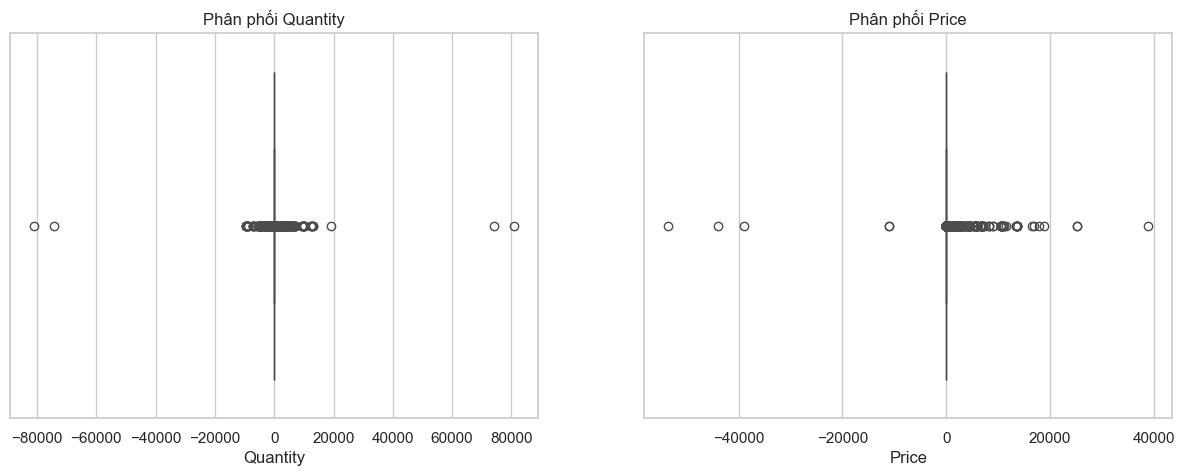

In [20]:
display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Quantity'], ax=axes[0]).set_title('Phân phối Quantity')
sns.boxplot(x=df['Price'], ax=axes[1]).set_title('Phân phối Price')
plt.show()


## Bước 3: Exploratory Data Analysis (EDA)
Khám phá các Insight đặc biệt từ dữ liệu.

### 3.1 Giao dịch theo Ngày trong tuần (Day of Week)
**Nhận xét:** Nhìn biểu đồ bạn sẽ thấy Thứ 7 gần như không có / hoặc hoàn toàn trống vắng các giao dịch.

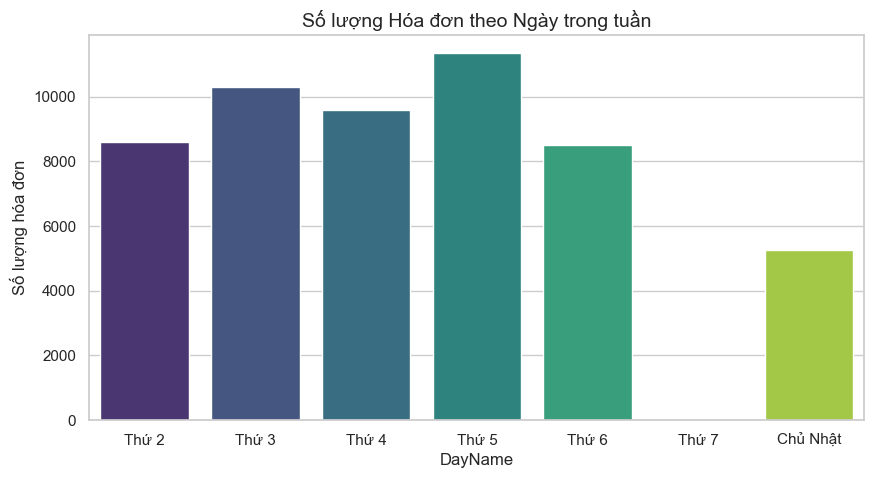

In [21]:
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
day_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df['DayName'] = df['DayOfWeek'].map(day_names)

transactions_by_day = df.groupby('DayName')['Invoice'].nunique().reindex(day_names.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=transactions_by_day.index, y=transactions_by_day.values, palette='viridis')
plt.title('Số lượng Hóa đơn theo Ngày trong tuần', fontsize=14)
plt.ylabel('Số lượng hóa đơn')
plt.show()


### 3.2 Phân tích Đơn hàng Hủy / Hoàn trả
**Nhận xét:** Hóa đơn bắt đầu bằng 'C' và `Quantity < 0` là đặc trưng của các đơn bị trả/hủy.

In [22]:
df['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
cancel_rate = df['Is_Cancelled'].mean() * 100
print(f"Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: {cancel_rate:.2f}%")
display(df[df['Is_Cancelled']].head())


Tỷ lệ dòng dữ liệu là đơn hủy/trả hàng: 1.83%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,DayOfWeek,DayName,Is_Cancelled
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,1,Thứ 3,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,1,Thứ 3,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,1,Thứ 3,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1,Thứ 3,True


### 3.3 Tập trung Địa lý (Country)
**Nhận xét:** Một đặc trưng cực kỳ rõ nét của bộ dataset này là thị trường tập trung vào United Kingdom.

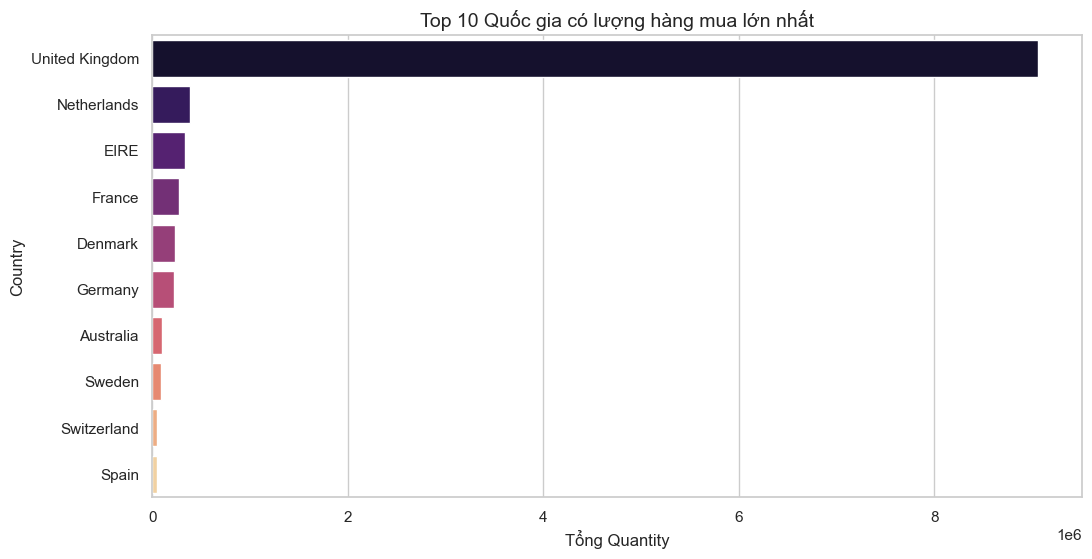

In [23]:
country_sales = df[~df['Is_Cancelled']].groupby('Country')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.head(10).values, y=country_sales.head(10).index, palette='magma')
plt.title('Top 10 Quốc gia có lượng hàng mua lớn nhất', fontsize=14)
plt.xlabel('Tổng Quantity')
plt.show()


### 3.4 Xu hướng theo Thời gian (Seasonality)
**Nhận xét:** Doanh thu tăng vọt ở quý 4 hằng năm (hiệu ứng mùa lễ hội cuối năm).

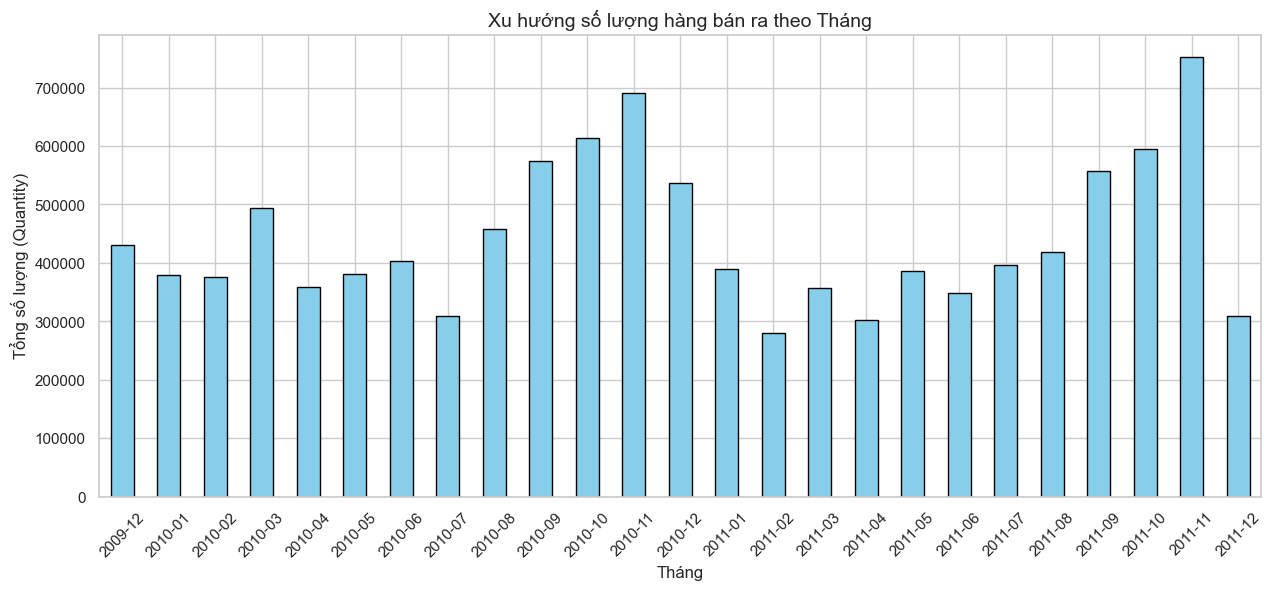

In [24]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
sales_trend = df[~df['Is_Cancelled']].groupby('YearMonth')['Quantity'].sum()

plt.figure(figsize=(15, 6))
sales_trend.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Xu hướng số lượng hàng bán ra theo Tháng', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Tổng số lượng (Quantity)')
plt.xticks(rotation=45)
plt.show()


## Bước 4: Data Cleaning, Xử lý Missing/Outlier & Chuyển đổi Biến Mục Tiêu (Log Transform)
Thực hiện đúng chiến lược đã chốt: Không dùng Winsorization, chỉ dọn rác, gom nhóm theo ngày và lấy Log1p.

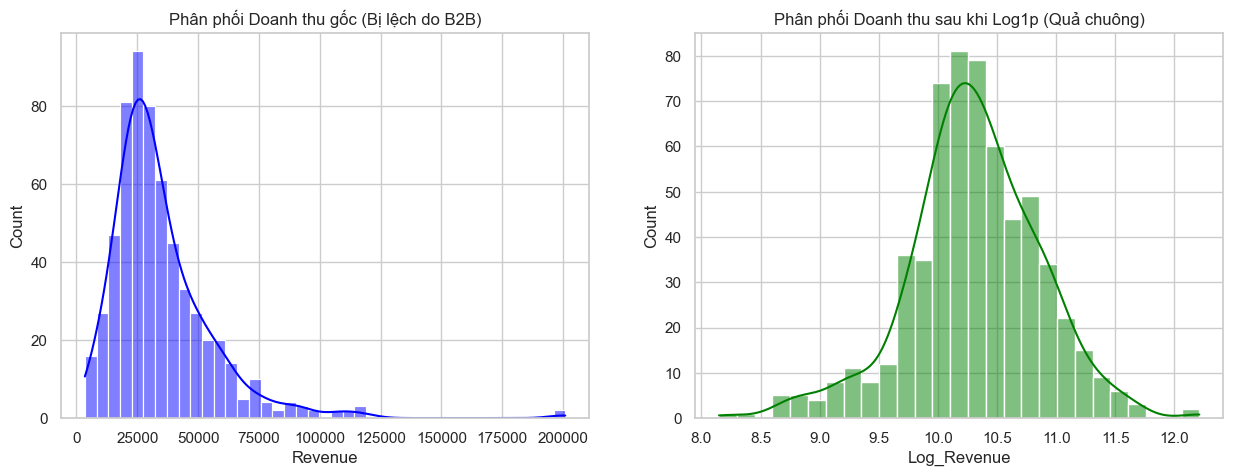

In [25]:
df['Customer ID'].fillna('Guest', inplace=True)
df['Description'].fillna('Unknown', inplace=True)

df_clean = df[(~df['Is_Cancelled']) & (df['Quantity'] > 0) & (df['Price'] > 0)].copy()
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate'].dt.date)

daily_sales = df_clean.groupby('Date')['Revenue'].sum().reset_index()
daily_sales['Log_Revenue'] = np.log1p(daily_sales['Revenue'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(daily_sales['Revenue'], kde=True, ax=axes[0], color='blue').set_title('Phân phối Doanh thu gốc (Bị lệch do B2B)')
sns.histplot(daily_sales['Log_Revenue'], kde=True, ax=axes[1], color='green').set_title('Phân phối Doanh thu sau khi Log1p (Quả chuông)')
plt.show()

daily_sales.set_index('Date', inplace=True)


## Bước 5: Bộ Feature Vàng (Feature Engineering) & Temporal Split
Tạo các đặc trưng Thời gian, Lag và Rolling. Tránh rò rỉ dữ liệu bằng cách DropNA và không trộn ngẫu nhiên khi cắt tập Test.

In [26]:
daily_sales['Day_of_Week'] = daily_sales.index.dayofweek
daily_sales['Month'] = daily_sales.index.month
daily_sales['Is_Weekend'] = (daily_sales['Day_of_Week'] == 6).astype(int)
daily_sales['Promo_Season'] = daily_sales['Month'].isin([9, 10, 11]).astype(int)

daily_sales['Lag_1'] = daily_sales['Log_Revenue'].shift(1)
daily_sales['Lag_7'] = daily_sales['Log_Revenue'].shift(7)
daily_sales['Rolling_Mean_7'] = daily_sales['Lag_1'].rolling(window=7).mean()
daily_sales['Rolling_Std_7'] = daily_sales['Lag_1'].rolling(window=7).std()

display(daily_sales.head(10))

daily_sales_final = daily_sales.dropna().copy()

train_data = daily_sales_final[daily_sales_final.index < '2011-05-01']
test_data = daily_sales_final[daily_sales_final.index >= '2011-05-01']

features = ['Day_of_Week', 'Month', 'Is_Weekend', 'Promo_Season', 'Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Rolling_Std_7']
X_train, y_train = train_data[features], train_data['Log_Revenue']
X_test, y_test = test_data[features], test_data['Log_Revenue']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


,Revenue,Log_Revenue,Day_of_Week,Month,Is_Weekend,Promo_Season,Lag_1,Lag_7,Rolling_Mean_7,Rolling_Std_7
Date,,,,,,,,,,
2009-12-01,54513.50,10.906222,1,12,0,0,NaN,NaN,NaN,NaN
2009-12-02,63352.51,11.056486,2,12,0,0,10.906222,NaN,NaN,NaN
2009-12-03,74037.91,11.212346,3,12,0,0,11.056486,NaN,NaN,NaN
2009-12-04,40732.92,10.614816,4,12,0,0,11.212346,NaN,NaN,NaN
2009-12-05,9803.05,9.190551,5,12,0,0,10.614816,NaN,NaN,NaN
2009-12-06,24613.64,10.111097,6,12,1,0,9.190551,NaN,NaN,NaN
2009-12-07,45083.35,10.716290,0,12,0,0,10.111097,NaN,NaN,NaN
2009-12-08,49517.23,10.810096,1,12,0,0,10.716290,10.906222,10.543973,0.694558
2009-12-09,40616.09,10.611944,2,12,0,0,10.810096,11.056486,10.530240,0.687112


## Bước 6: Model Training & Evaluation (One-step Ahead)
Train 5 mô hình ML truyền thống cho bài toán Regression, tính MAE, RMSE bằng số Bảng Anh thực tế (thông qua hàm `expm1`).

In [27]:
models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

results = []
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test) 
    
    predictions_dict[name] = y_pred_actual
    
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    
    results.append({'Model': name, 'MAE (£)': mae, 'RMSE (£)': rmse})

df_results = pd.DataFrame(results).sort_values(by='MAE (£)')
display(df_results)


,Model,MAE (£),RMSE (£)
0,Linear Regression,10916.889186,18025.127697
1,KNN Regressor,11023.573467,17663.500674
3,Random Forest,11223.105064,17686.382674
4,SVR,11806.411776,18283.733266
2,Decision Tree,16438.699931,24421.532995


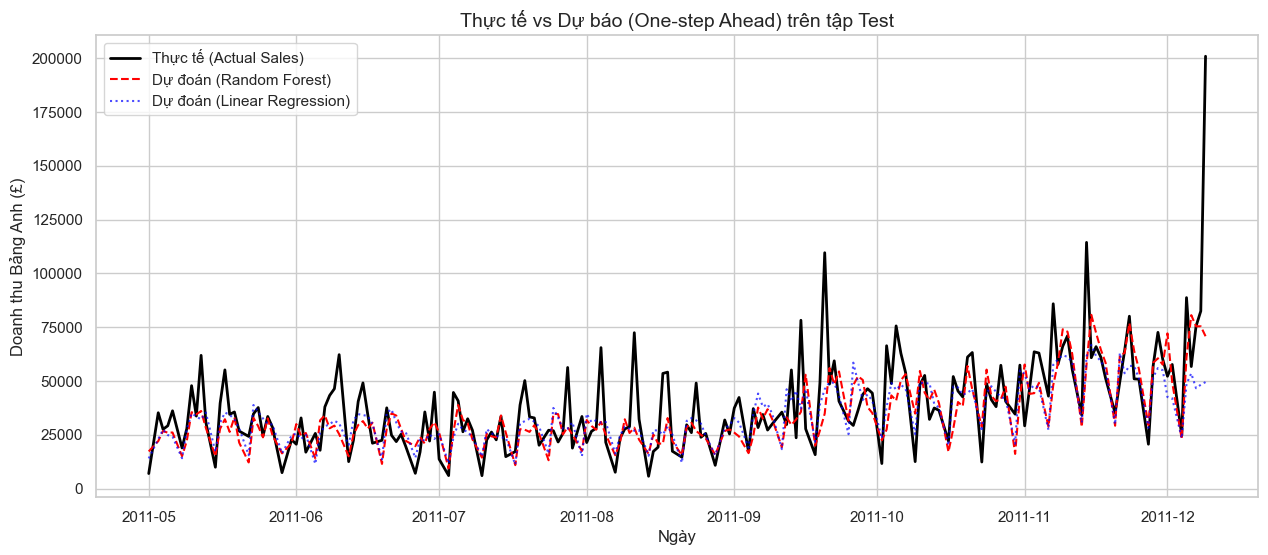

In [28]:
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, y_test_actual, label='Thực tế (Actual Sales)', color='black', linewidth=2)
plt.plot(test_data.index, predictions_dict['Random Forest'], label='Dự đoán (Random Forest)', color='red', linestyle='--')
plt.plot(test_data.index, predictions_dict['Linear Regression'], label='Dự đoán (Linear Regression)', color='blue', linestyle=':', alpha=0.7)
plt.title('Thực tế vs Dự báo (One-step Ahead) trên tập Test', fontsize=14)
plt.xlabel('Ngày')
plt.ylabel('Doanh thu Bảng Anh (£)')
plt.legend()
plt.show()
